![орп](xi_test.png)
1. Начнем с проверки простой гипотезы.
Найдите первые 1000 цифр числа π после запятой. С помощью критерия хи-квадрат проверьте,
можно ли при уровне значимости 0.05 считать эти цифры случайными равномерными?

1000
[0.093 0.116 0.103 0.102 0.093 0.097 0.094 0.095 0.101 0.106]
статистика при H0 = 4.739999999999999, квантиль уровня 1 - alpha = 16.918977604620448
Гипотезу принимаем


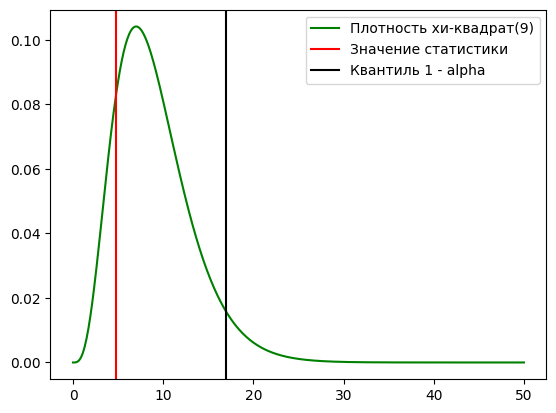

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from mpmath import mp #для пи
mp.dps = 1001
#H0: первые 1000 цифр равномерны на {0,...,9}, т.е. каждое встречается с вероятностью 1/10
#H1: не H0
#План такой - посчитать статистику при H0, если она окажется больше чем квантиль 0.05 распределения, к которому она стремится, то отвергаем, если нет - принимаем
def yest_a_hypothesis(alpha, n, p):
    pi_str = str(mp.pi)[2:1003]
    quantity = np.array([0] * 10) #массив для абсолютных частот, они в формуле нюi
    for digit in pi_str:
        i = int(digit)
        quantity[i] += 1
    print(np.sum(quantity))
    frequency = quantity / n 
    print(frequency)#это относительные чатоты, ожидаемые все равны 0.1
    statistic = np.sum(((quantity - n * p)**2) / (n * p)) #должна стремиться к хи-квадрат (n-1)
    #ppf = Percent Point Function = Обратная функция распределения = квантиль
    alphath_quantile = stats.chi2.ppf(1 - alpha, df = 9) # df - степени свободы, хотим чтобы P(statistic < q_1-alpha) = 1 - alpha при H0
    print(f"статистика при H0 = {statistic}, квантиль уровня 1 - alpha = {alphath_quantile}")
    if statistic > alphath_quantile:
        print(f"Гипотезу отвергаем")
    else:
        print(f"Гипотезу принимаем")
    x = np.linspace(0, 50, 500)
    y = stats.chi2.pdf(x, df=9)
    plt.plot(x, y, color = 'green', label = "Плотность хи-квадрат(9)")
    plt.axvline(statistic, color = 'red', label = 'Значение статистики')
    plt.axvline(alphath_quantile, color = 'black', label = 'Квантиль 1 - alpha')
    plt.legend()
    plt.show()
        
alpha = 0.05
n = 1000
p = 0.1
yest_a_hypothesis(alpha, n, p)        
    

2. Проверим однородность и независимость. Использовать данные из файла Priem.csv и встроенный
критерий.

(a) Ответить на вопрос - отличаются ли мальчики и девочки в плане успешности сдачи ЕГЭ?
Для этого попарно проверьте на однородность суммарные баллы, баллы по русскому, баллы
по математике.

(b) Правда ли, что оценки по математике и русскому независимы?

В статистике проверка однородности (или тест на однородность) используется для того, чтобы ответить на вопрос: «Взяты ли две (или более) выборки из одного и того же распределения?» Или, другими словами: «Есть ли статистически значимые различия между двумя группами по интересующему нас признаку?»

В нашем случае признак — успешность сдачи ЕГЭ, а группы — мальчики и девочки.

Мы выдвигаем две гипотезы:

H₀ (Нулевая гипотеза): Распределение успешности сдачи ЕГЭ у мальчиков и девочек одинаково (однородно). Различия между ними случайны.(то есть равномерное по группам)

H₁ (Альтернативная гипотеза): Распределения различаются. Успешность зависит от пола.

In [ ]:
import pandas as pd
from scipy.stats import chi2_contingency

df = pd.read_csv('Priem.csv', sep=';', quotechar='"', encoding='cp1251')
df.columns = df.columns.str.strip()

def check_homogeneity(data, score_column):
    data_clean = data.dropna(subset=[score_column, 'Пол']).copy()    
    data_clean.loc[:, score_column] = pd.to_numeric(data_clean[score_column], errors='coerce')
    data_clean = data_clean.dropna(subset=[score_column])
    try:
        data_clean.loc[:, 'group'] = pd.qcut(data_clean[score_column], q=3, labels=['Низкий', 'Средний', 'Высокий'])
    except Exception as e:
        print(f"Не удалось разбить на группы: {e}")
        return None
    
    table = pd.crosstab(data_clean['Пол'], data_clean['group'])
    
    print("Таблица наблюдаемых частот:")
    print(table)
    
    chi2, p_value, dof, expected = chi2_contingency(table)
    
    print(f"Статистика χ² = {chi2:.3f}")
    print(f"p-value = {p_value:.4f}")
    
    if p_value < 0.05:
        print(f"мальчики и девочки РАЗЛИЧАЮТСЯ по {score_column}")
    else:
        print(f"мальчики и девочки НЕ РАЗЛИЧАЮТСЯ по {score_column}")
    
    return p_value

p_sum = check_homogeneity(df, 'Сумма.баллов')
p_rus = check_homogeneity(df, 'ЕГЭ...рус.яз.')
p_math = check_homogeneity(df, 'ЕГЭ...матем.')


Таблица наблюдаемых частот:
group    Низкий  Средний  Высокий
Пол                              
ЖЕНСКИЙ     160      148      158
МУЖСКОЙ     306      312      306
Статистика χ² = 0.572
p-value = 0.7514
мальчики и девочки НЕ РАЗЛИЧАЮТСЯ по Сумма.баллов
Таблица наблюдаемых частот:
group    Низкий  Средний  Высокий
Пол                              
ЖЕНСКИЙ     105      173      188
МУЖСКОЙ     384      320      217
Статистика χ² = 62.564
p-value = 0.0000
мальчики и девочки РАЗЛИЧАЮТСЯ по ЕГЭ...рус.яз.
Таблица наблюдаемых частот:
group    Низкий  Средний  Высокий
Пол                              
ЖЕНСКИЙ     183      167      116
МУЖСКОЙ     353      330      236
Статистика χ² = 0.135
p-value = 0.9348
мальчики и девочки НЕ РАЗЛИЧАЮТСЯ по ЕГЭ...матем.


3. Построим критерий Кресси-Рида для проверки простой гипотезы о полиномиальном распреде-
лении. Давайте сравним наши критерии для различных λ. Рассмотрите λ, равные −1, 0, 0.5, 1, 2.

Поcтройте график p-value для каждого из них и выберите наиболее удачный критерий. Исполь-
зуйте исходное равномерное распределение (все pi равны) и неравномерное на свой вкус.

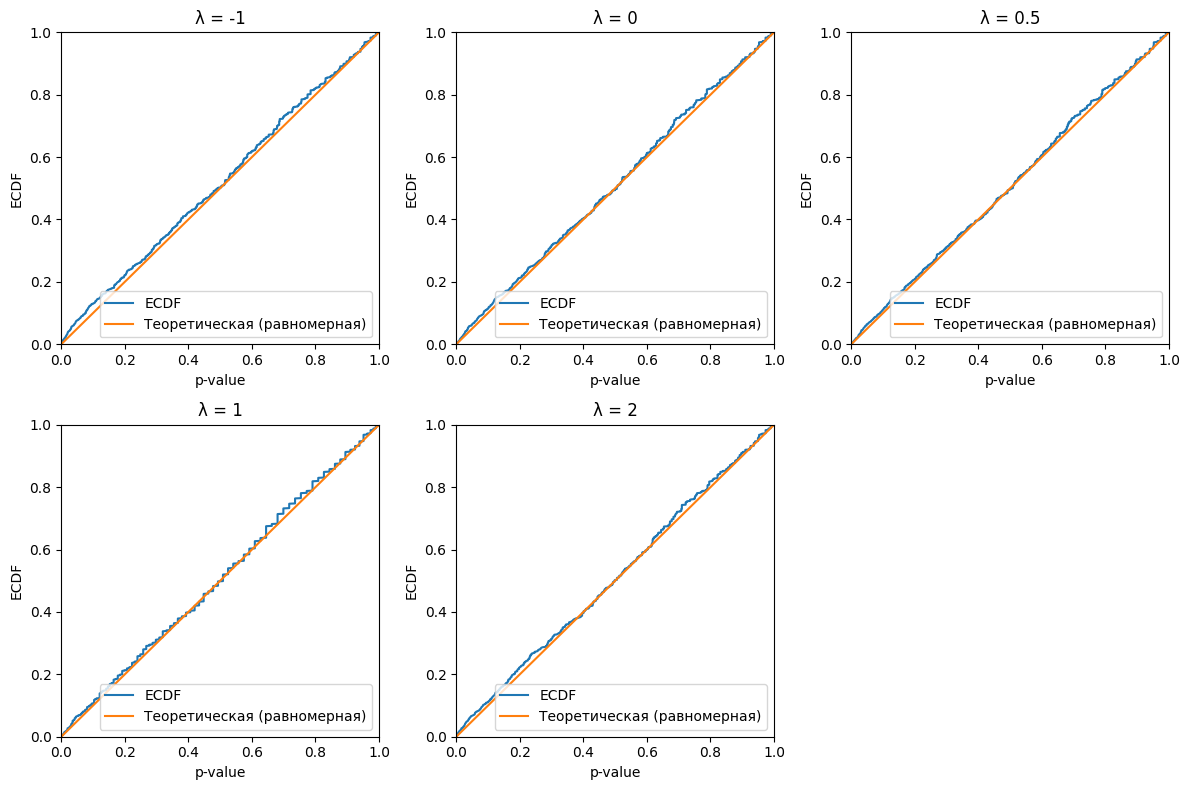

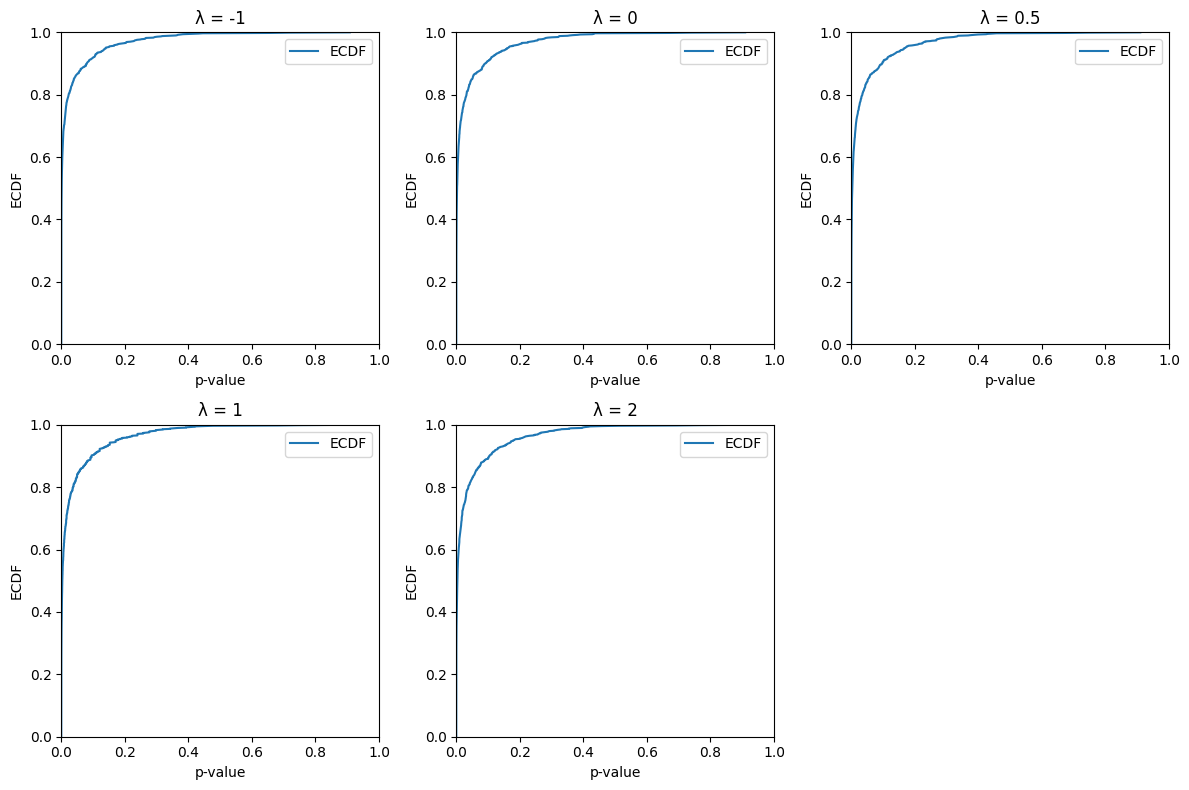

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2
from statsmodels.distributions.empirical_distribution import ECDF

def cressie_read_statistic(nu, n, p, lam):
    k = len(nu)
    statistic = 0
    if lam == -1:
        for i in range(k):
            if nu[i] > 0 and p[i] > 0:
                statistic += n * p[i] * np.log(n * p[i] / nu[i])
        statistic = 2 * statistic
    elif lam == 0:
        for i in range(k):
            if nu[i] > 0 and p[i] > 0:
                statistic += nu[i] * np.log(nu[i] / (n * p[i]))
        statistic = 2 * statistic
    else:
        for i in range(k):
            if nu[i] > 0 and p[i] > 0:
                ratio = nu[i] / (n * p[i])
                statistic += nu[i] * (ratio**lam - 1)
        statistic = (2 / (lam * (lam + 1))) * statistic
    return statistic

def ecdf_pvalue(n, k, p_true, p_h0, lam_values, n_simulations=1000):
    results = {lam: [] for lam in lam_values}
    for _ in range(n_simulations):
        nu = np.random.multinomial(n, p_true) #полиномиальное 
        for lam in lam_values:
            stat = cressie_read_statistic(nu, n, p_h0, lam)
            # p-value = 1 - CDF хи-квадрат с k-1 степенями свободы
            p_value = 1 - chi2.cdf(stat, k-1)
            results[lam].append(p_value)
    return results

n = 100  
k = 5   
n_simulations = 2000
lam_values = [-1, 0, 0.5, 1, 2]

p_uniform = np.ones(k) / k  # все вероятности равны 1/k
results_uniform = ecdf_pvalue(n, k, p_uniform, p_uniform, lam_values)
plt.figure(figsize=(12, 8))
x_theor = np.linspace(0, 1, 100)
y_theor = x_theor 
for i, lam in enumerate(lam_values):
    plt.subplot(2, 3, i+1)
    pvalue_ecdf_un = ECDF(results_uniform[lam])  
    plt.plot(pvalue_ecdf_un.x, pvalue_ecdf_un.y, label='ECDF')
    plt.plot(x_theor, y_theor, label='Теоретическая (равномерная)')
    plt.xlabel('p-value')
    plt.ylabel('ECDF')
    plt.title(f'λ = {lam}')
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.legend()
plt.tight_layout()
plt.show()


p_true_nonuniform = np.array([0.3, 0.25, 0.2, 0.15, 0.1])
results_nonuniform = ecdf_pvalue(n, k, p_true_nonuniform, p_uniform, lam_values)
plt.figure(figsize=(12, 8))
for i, lam in enumerate(lam_values):
    plt.subplot(2, 3, i+1)
    pvalue_ecdf_nonun = ECDF(results_nonuniform[lam]) 
    plt.plot(pvalue_ecdf_nonun.x, pvalue_ecdf_nonun.y, label='ECDF')    
    plt.xlabel('p-value')
    plt.ylabel('ECDF')
    plt.title(f'λ = {lam}')
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.legend()
plt.tight_layout()
plt.show()